# Sheet 3

- Anna Bütfering
- Lea Neumann
- Juan Provencio

## Task 1
Two moons with an invertible neural network

In [12]:
import math
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

In [13]:
# Coupling Layer for RealNVP with forward and inverse methods
class CouplingLayer(nn.Module):
    def __init__(self, input_size, hidden_size, mask):
        """
        input_size : dimension of x (2 for two moons)
        hidden_size : width of the internal networks
        mask : boolean tensor of shape (input_size,)
               True  -> passthrough part (x1)
               False -> transformed part (x2)
        """
        super().__init__()
        self.mask = mask

        in_dim = int(mask.sum().item())
        out_dim = input_size - in_dim  # number of transformed dims

        # translation
        self.t_net = nn.Sequential(
            nn.Linear(in_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, out_dim)
        )

        # scaling
        self.s_net = nn.Sequential(
            nn.Linear(in_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, out_dim)
        )


    def forward(self, x):
        x1 = x[:, self.mask]      # unchanged part
        x2 = x[:, ~self.mask]     # transformed part

        t = self.t_net(x1)
        s_tilde = self.s_net(x1)
        s = torch.exp(torch.tanh(s_tilde))  # ensures positive, controlled scaling

        y2 = x2 * s + t

        # combine back into full vector
        y = x.clone()
        y[:, ~self.mask] = y2

        # log-det Jacobian = sum(log(s))
        log_det = torch.sum(torch.log(s), dim=1)

        return y, log_det

    def inverse(self, y):
        y1 = y[:, self.mask]
        y2 = y[:, ~self.mask]

        t = self.t_net(y1)
        s_tilde = self.s_net(y1)
        s = torch.exp(torch.tanh(s_tilde))

        x2 = (y2 - t) / s

        x = y.clone()
        x[:, ~self.mask] = x2

        log_det = -torch.sum(torch.log(s), dim=1)

        return x, log_det

In [14]:
# defining the RealNVP model
class RealNVP(nn.Module):
    def __init__(self, input_size, hidden_size, blocks, device='cpu'):
        super().__init__()
        self.input_size = input_size
        self.blocks = blocks
        self.device = device

        # alternating masks for coupling layers (swap which half is transformed)
        masks = []
        for b in range(blocks):
            if b % 2 == 0:
                mask = torch.tensor([True, False])   # first dim passthrough
            else:
                mask = torch.tensor([False, True])   # second dim passthrough
            masks.append(mask)

        # create coupling layers for each mask
        self.couplings = nn.ModuleList([
            CouplingLayer(input_size, hidden_size, mask)
            for mask in masks
        ])

        # random orthonormal rotations (except after last block)
        self.register_buffer('rotations', torch.stack([
            self._random_ortho(input_size) for _ in range(blocks - 1)
        ]) if blocks > 1 else torch.empty(0))

    def _random_ortho(self, dim):
        #Create a random orthonormal matrix using QR decomposition.
        a = torch.randn(dim, dim)
        q, r = torch.qr(a)
        if torch.det(q) < 0:
            q[:, 0] = -q[:, 0]
        return q

    def forward(self, x):
        #Encoder: x -> z
        log_det_tot = x.new_zeros(x.shape[0])
        y = x
        for i, c in enumerate(self.couplings):
            y, logd = c.forward(y)
            log_det_tot = log_det_tot + logd
            # apply rotation if not last block
            if i < len(self.couplings) - 1:
                R = self.rotations[i].to(x.device)
                y = (R @ y.t()).t()
        return y, log_det_tot

    def inverse(self, z):
        #Decoder: z -> x
        log_det_tot = z.new_zeros(z.shape[0])
        y = z
        for i in reversed(range(len(self.couplings))):
            # inverse rotation if not last in reverse
            if i < len(self.couplings) - 1:
                R = self.rotations[i].to(z.device)
                y = (R.t() @ y.t()).t()  # transpose = inverse for orthonormal
            y, logd = self.couplings[i].inverse(y)
            log_det_tot = log_det_tot + logd
        return y, log_det_tot

    def sample(self, num_samples):
        #Generate samples: z ~ N(0,I) -> x
        z = torch.randn(num_samples, self.input_size, device=next(self.parameters()).device)
        x, _ = self.inverse(z)
        return x.detach().cpu().numpy()


In [15]:
# minimal training loop for RealNVP on two moons dataset
def train_realnvp(model, data, batch_size, epochs=1000, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    N = data.shape[0]

    epoch_losses = []

    for epoch in range(epochs):
        perm = torch.randperm(N)
        epoch_loss = 0.0

        for i in range(0, N, batch_size):
            idx = perm[i:i+batch_size]
            x_batch = data[idx].to(next(model.parameters()).device)

            optimizer.zero_grad()

            # forward pass: x -> z, log_det
            z, log_det = model.forward(x_batch)

            # negative log-likelihood -> our loss function
            log_p_z = -0.5 * torch.sum(z ** 2, dim=1) - 0.5 * model.input_size * np.log(2*np.pi)
            nll = - (log_p_z + log_det)
            loss = nll.mean()

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * x_batch.shape[0]

        epoch_loss /= N
        epoch_losses.append(epoch_loss)
        print(f"Epoch {epoch+1}/{epochs}, NLL: {epoch_loss:.4f}")
        
    return epoch_losses

Epoch 1/1000, NLL: 2.4920
Epoch 2/1000, NLL: 2.1903
Epoch 3/1000, NLL: 2.0043
Epoch 4/1000, NLL: 1.8901
Epoch 5/1000, NLL: 1.8206
Epoch 6/1000, NLL: 1.7746
Epoch 7/1000, NLL: 1.7405
Epoch 8/1000, NLL: 1.7151
Epoch 9/1000, NLL: 1.6922
Epoch 10/1000, NLL: 1.6726
Epoch 11/1000, NLL: 1.6561
Epoch 12/1000, NLL: 1.6421
Epoch 13/1000, NLL: 1.6268
Epoch 14/1000, NLL: 1.6153
Epoch 15/1000, NLL: 1.6037
Epoch 16/1000, NLL: 1.5901
Epoch 17/1000, NLL: 1.5841
Epoch 18/1000, NLL: 1.5745
Epoch 19/1000, NLL: 1.5607
Epoch 20/1000, NLL: 1.5516
Epoch 21/1000, NLL: 1.5402
Epoch 22/1000, NLL: 1.5345
Epoch 23/1000, NLL: 1.5314
Epoch 24/1000, NLL: 1.5138
Epoch 25/1000, NLL: 1.5042
Epoch 26/1000, NLL: 1.4983
Epoch 27/1000, NLL: 1.4918
Epoch 28/1000, NLL: 1.4852
Epoch 29/1000, NLL: 1.4798
Epoch 30/1000, NLL: 1.4748
Epoch 31/1000, NLL: 1.4750
Epoch 32/1000, NLL: 1.4709
Epoch 33/1000, NLL: 1.4700
Epoch 34/1000, NLL: 1.4606
Epoch 35/1000, NLL: 1.4601
Epoch 36/1000, NLL: 1.4683
Epoch 37/1000, NLL: 1.4414
Epoch 38/1

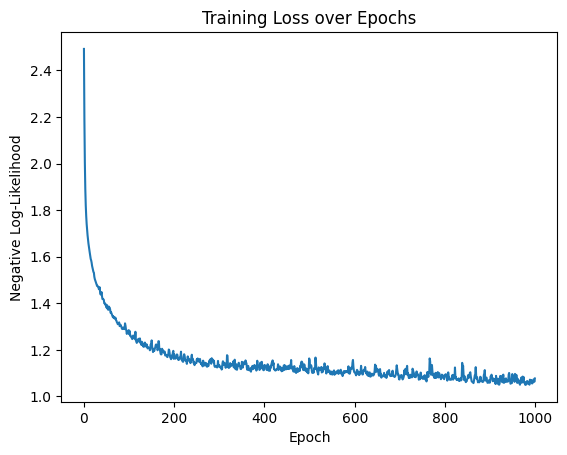

Reconstruction error: tensor(1.2517e-06, grad_fn=<MaxBackward1>)


In [ ]:
# generate two moons dataset
X, _ = make_moons(n_samples=1000, noise=0.1)
X = torch.tensor(X, dtype=torch.float32)

# create RealNVP
model = RealNVP(input_size=2, hidden_size=32, blocks=4)

# train with high epochs
for epochs in [10, 50, 100]:
    losses=train_realnvp(model, X, batch_size=128, epochs=epochs, lr=1e-3)
    plt.plot(losses, label=f"{epochs} epochs")
plt.legend()
plt.show()


#plotting loss function over epochs
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Negative Log-Likelihood")
plt.title("Training Loss over Epochs")
plt.show()



# check if reverse pass is the inverse of forward pass 
x_sample = X[:10]
z, _ = model.forward(x_sample)
x_reconstructed, _ = model.inverse(z)
print("Reconstruction error:", torch.max(torch.abs(x_sample - x_reconstructed)))

In [ ]:
# train for different training set sizes (1000,5000,10000)
for epochs in [10, 50, 100]:
    losses=train_realnvp(model, X, batch_size=128, epochs=epochs, lr=1e-3)
    plt.plot(losses, label=f"{epochs} epochs")
plt.legend()
plt.show()


#plotting loss function
plt.plot(losses)
plt.xlabel("training set sizes")
plt.ylabel("Negative Log-Likelihood")
plt.title("Training Loss over Epochs")
plt.show()



# check if reverse pass is the inverse of forward pass 
x_sample = X[:10]
z, _ = model.forward(x_sample)
x_reconstructed, _ = model.inverse(z)
print("Reconstruction error:", torch.max(torch.abs(x_sample - x_reconstructed)))